<a href="https://colab.research.google.com/github/abhishekanand04/ML-Adv-Supervised-Alogorithms/blob/mladv/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!gdown 1UZNOcb-bSL-aPPXWcPH4h4Kbx4G-bk9J


Downloading...
From: https://drive.google.com/uc?id=1UZNOcb-bSL-aPPXWcPH4h4Kbx4G-bk9J
To: /content/mnist_train.csv
100% 76.8M/76.8M [00:01<00:00, 74.4MB/s]


In [ ]:
d0 = pd.read_csv('mnist_train.csv')

print(d0.head(5)) # print first five rows of d0.

# save the labels into a variable l.
l = d0['label']

# Drop the label feature and store the pixel data in d.
d = d0.drop("label",axis=1)

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [ ]:
d.shape

(42000, 784)

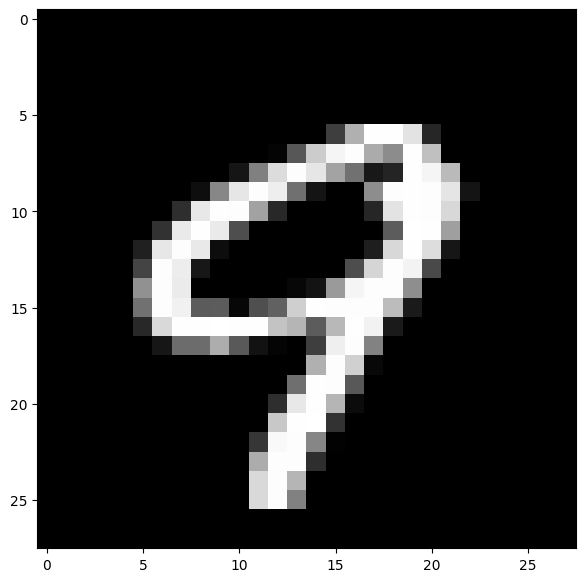

9


In [ ]:
plt.figure(figsize=(7,7))
idx = 100

grid_data = d.iloc[idx].values.reshape(28, 28)  # reshape from 1d to 2d pixel array
plt.imshow(grid_data, interpolation = "none", cmap = "gray")
plt.show()

print(l[idx])

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
from sklearn import datasets

digits = datasets.load_digits()

X=digits.data
print(X.shape)

(1797, 64)


In [ ]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

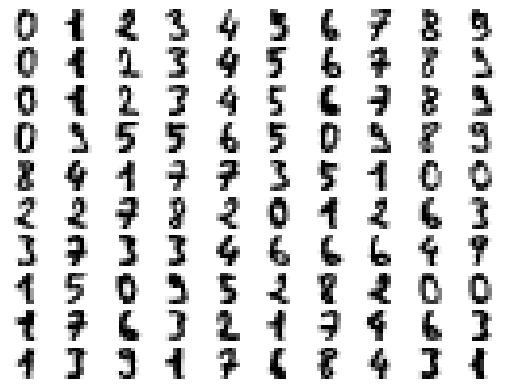

In [ ]:
import matplotlib.pyplot as plt

plt.set_cmap('binary') # set the colourmap to grayscale white to black

for i in range(10):
  for j in range(10):
   ax = plt.subplot(10,10,1+10*i+j)
   ax.axis('off')
   ax.matshow(digits.images[10*i+j])

plt.show()
plt.close()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)

X_stand = scaler.transform(X)

In [ ]:
%%time

pca = PCA(n_components = 2)

X_embedded = pca.fit_transform(X_stand)


print(X_embedded.shape)

(1797, 2)
CPU times: user 19.2 ms, sys: 0 ns, total: 19.2 ms
Wall time: 27 ms


NameError: name 'X_embedded' is not defined

<Figure size 640x480 with 0 Axes>

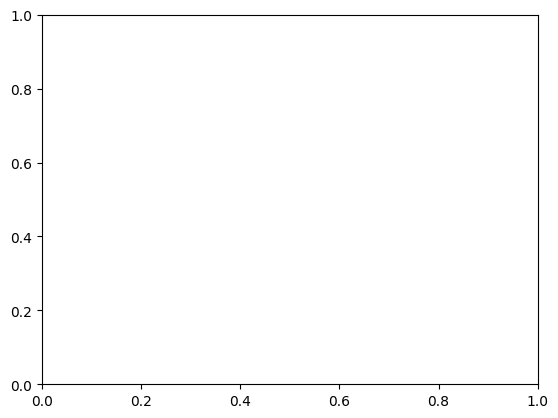

In [ ]:
plt.set_cmap('tab10')

fig, ax = plt.subplots()

scatter = ax.scatter(X_embedded[:,0],X_embedded[:,1],c=digits.target)
legend = ax.legend(*scatter.legend_elements(),loc="upper left")
ax.add_artist(legend)

plt.show()
plt.close()

In [ ]:
%%time
from sklearn.manifold import TSNE
z2 = TSNE(n_jobs=-1, random_state=42).fit_transform(X)

CPU times: user 19 s, sys: 132 ms, total: 19.1 s
Wall time: 30.2 s


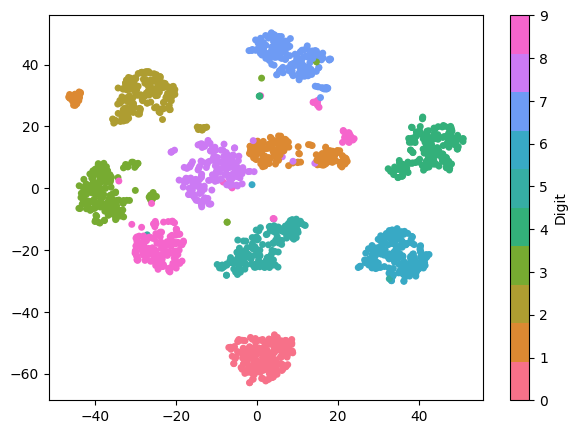

In [ ]:
import seaborn as sns
import numpy as np

Y = digits.target
fig, ax = plt.subplots(figsize=[7,5])

from matplotlib.colors import ListedColormap
cmap = ListedColormap(sns.husl_palette(len(np.unique(Y))))

im = ax.scatter(z2[:,0], z2[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')

In [ ]:
!pip install umap-learn

In [ ]:
%%time
from umap import UMAP
z3 = UMAP().fit_transform(X)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


CPU times: user 23.1 s, sys: 605 ms, total: 23.7 s
Wall time: 36.3 s


In [ ]:
Y = digits.target

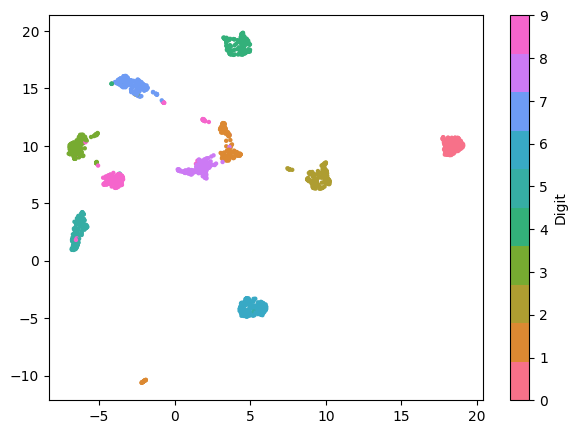

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import numpy as np
fig, ax = plt.subplots(figsize=[7,5])
cmap = ListedColormap(sns.husl_palette(len(np.unique(Y))))
im = ax.scatter(z3[:,0], z3[:,1], s=10, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')